# 🚀 完整DMPC框架: Flow Matching + CBF +MLP intercation





# 🔧 修正版 DMPC + Flow Matching 框架

---

## 📋 主要修改

本notebook是修正版,解决了原版本中的关键问题:

### ❌ 原版本问题
1. **Flow Matching预测了50步,但只使用了第2个点** - 浪费了预测信息
2. **缺少reward函数和value function** - 无法评估轨迹质量
3. **单步优化而非MPC** - 实际上是贪心算法

### ✅ 修正版改进
1. **完整利用Flow Matching预测** - 评估整条未来轨迹(50步)
2. **添加reward和value function** - 正确评估轨迹代价
3. **真正的MPC优化** - 基于未来N步做当前决策

---

## 🎯 核心架构

每一步DMPC循环:

```
1. 预测: Flow Matching预测未来50步 → [x₀, x₁, ..., x₄₉]
2. 评估: 计算总代价 J = Σ(reward₀→₄₈) + V(x₄₉)
3. 选择: 提取最优轨迹的第一步控制 u₀
4. 执行: 应用CBF确保安全,更新状态
5. 循环: 用新状态重新预测(滚动优化)
```

---

## 📝 新增函数

- `compute_stage_reward(x, u, goal, obstacles)` - 计算单步奖励
- `compute_terminal_value(x_terminal, goal, obstacles)` - 计算终端价值
- `evaluate_trajectory_cost(trajectory, ...)` - 评估整条轨迹
- `dmpc_step_corrected(...)` - 修正的DMPC单步优化
- `dmpc_rollout_corrected(...)` - 修正的完整滚动循环

---

## ⚙️ 关键参数

调用`dmpc_rollout_corrected`时的重要参数:

- `horizon=50` - 预测视野(每次预测多少步)
- `n_samples=3` - 采样数量(每次尝试几条候选轨迹)
- `dt=0.02` - 时间步长

---

## 🚀 运行说明

1. 按顺序运行所有cell
2. 观察输出中的`MPC_cost`值 - 这表示轨迹的总代价
3. `MPC_cost`应该随着接近目标而增加(变得不那么负)

---

**修正时间**: 2024-11-16  
**修正要点**: Flow Matching作为动态模型 + MPC优化框架 + CBF安全保证


In [1]:
# ===============================================================
# 导入库和环境设置
# ===============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cvxpy as cp
import os

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  使用设备: {device}")
print(f"📦 PyTorch版本: {torch.__version__}")
print(f"📦 CVXPY版本: {cp.__version__}")
print()

# 设置matplotlib
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 10

print("✅ 环境设置完成")

🖥️  使用设备: cuda
📦 PyTorch版本: 2.8.0+cu129
📦 CVXPY版本: 1.7.3

✅ 环境设置完成


In [2]:
# ===============================================================
# Flow Matching 基础组件（简化版：FM + ODE + CBF）
# ===============================================================

import torch
import torch.nn as nn

# ---------- 1. 如果没有 fmtorch，就用简化的 CondOTScheduler / AffinePath / ModelWrapper ----------
try:
    from fmtorch.scheduler import CondOTScheduler
    from fmtorch.path import AffinePath
    from fmtorch.utils import ModelWrapper
    FMTORCH_AVAILABLE = True
    print("✅ fmtorch 可用，训练会用到 CondOTScheduler / AffinePath")
except ImportError:
    FMTORCH_AVAILABLE = False
    print("⚠️ fmtorch 未安装，将使用简化版 CondOTScheduler / AffinePath / ModelWrapper（只用于训练）")
    
    class CondOTScheduler:
        def sigma_t(self, t):
            # 这里只是占位实现，保证训练代码能跑
            return 1e-5 * torch.ones_like(t)

    class AffinePath:
        def __init__(self, scheduler):
            self.scheduler = scheduler
        
        def sample(self, x_0, x_1, t):
            """
            简单线性插值路径:
                x_t = (1 - t) * x_0 + t * x_1
                dx_t = x_1 - x_0
            """
            if t.dim() == 1:
                t = t.view(-1, 1, 1)  # (B,1,1)
            x_t = (1 - t) * x_0 + t * x_1
            dx_t = x_1 - x_0

            class PathSample:
                pass
            sample = PathSample()
            sample.x_t = x_t
            sample.dx_t = dx_t
            sample.t = t
            return sample

    class ModelWrapper(nn.Module):
        """
        简单包装一下模型，统一接口：
            wrapped_model(x, t) -> model(x, t)
        """
        def __init__(self, model):
            super().__init__()
            self.model = model
        
        def forward(self, x, t, **kwargs):
            if t.dim() == 2:
                t = t.squeeze(-1)
            return self.model(x, t)

# ---------- 2. 椭圆障碍物的 h(x) 和 ∇h(x)（世界坐标下） ----------
def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
    """
    x_world_2N: (2, N)
    ellipse: {"center": np.array([cx,cy]), "radius": r}

    返回:
        h_e:    (N,)   h(x) = ||x-c||^2 - r^2
        grad_w: (N,2) ∇h(x) = 2(x-c)
    """
    if not torch.is_tensor(x_world_2N):
        x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)

    center = ellipse["center"]
    radius = ellipse["radius"]

    if not torch.is_tensor(center):
        center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

    x_N2 = x_world_2N.transpose(0, 1)   # (N,2)
    delta = x_N2 - center.view(1, 2)    # (N,2)

    dist_sq = (delta ** 2).sum(dim=1)   # (N,)
    h_e = dist_sq - float(radius) ** 2  # (N,)

    grad_w = 2.0 * delta                # (N,2)
    return h_e, grad_w


# ---------- 3. CBF 速度投影：直接在世界坐标里修 v ----------
@torch.no_grad()

def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 新增：两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # (1,2,N) or None
    agent_safe_radius: float = 0.5,
    # ★ 新增：压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物 [{"center": np.array, "radius": r}, ...] 或 []
      - other_agent_traj: (1,2,N)，另一辆车的整条轨迹（两车对开场景）
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    B, D, N = x_1x2N.shape  # (1,2,N)
    assert B == 1 and D == 2

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)  # (N,)
        P = press_k / dist.pow(press_n)                        # (N,)
    else:
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)  # h: (N,), grad: (N,2)
                h_eff = h_e - float(extra_margin)                  # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                          # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h          # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2              # (N,)
            grad_agent = 2.0 * delta_agent                        # (N,2)

            alpha_h_agent = gamma_x * h_agent                     # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


✅ fmtorch 可用，训练会用到 CondOTScheduler / AffinePath


In [3]:
import torch 
import torch.nn as nn
import numpy as np

try:
    import torchdiffeq
    HAS_TORCHDIFFEQ = True
    print("✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器")
except ImportError:
    HAS_TORCHDIFFEQ = False
    print("⚠️ 未安装 torchdiffeq，将退化为简单 Euler 积分")


class ODESolver:
    """
    Flow Matching 轨迹 ODE：
      - 状态是一整条轨迹 x ∈ R^{1×2×N}
      - dx/dt = v_theta(x,t, cond)，如需要可加入 CBF 修正
    """
    def __init__(self,
                 model,
                 traj_len=100,
                 T_final=1.0,
                 use_cbf=False,
                 ellipses=None,
                 cbf_passes=1,
                 cbf_margin=0.05,
                 cbf_max_corr_norm=0.5,
                 solver_method="dopri5",
                 solver_tolerance=1e-5,
                 # ★ 新增：条件向量 (例如 (cosθ, sinθ))
                 cond_vec: torch.Tensor = None,
                 # ★ 新增：两车 / 压强 CBF 所需参数
                 other_agent_traj: torch.Tensor = None,
                 agent_safe_radius: float = 0.5,
                 gamma_min: float = 1.0,
                 w_p: float = 5.0,
                 press_k: float = 1.0,
                 press_n: float = 2.0,
                 ):
        self.model = model
        self.traj_len = traj_len
        self.T_final = T_final
        self.use_cbf = use_cbf
        self.ellipses = ellipses or []
        self.cbf_passes = cbf_passes
        self.cbf_margin = cbf_margin
        self.cbf_max_corr_norm = cbf_max_corr_norm
        self.solver_method = solver_method
        self.solver_tolerance = solver_tolerance

        # 条件向量（例如 (cosθ, sinθ)）
        if cond_vec is not None:
            # 统一成 (1, cond_dim)
            self.cond_vec = cond_vec.detach().clone().view(1, -1)
        else:
            self.cond_vec = None

        # CBF 参数
        self.other_agent_traj = other_agent_traj
        self.agent_safe_radius = agent_safe_radius
        self.gamma_min = gamma_min
        self.w_p = w_p
        self.press_k = press_k
        self.press_n = press_n

    def _fm_ode_func(self, t, x_flat):
        """
        t: 标量时间 (torch scalar)
        x_flat: 展平后的轨迹 (2*N,)
        返回: 展平后的速度 (2*N,)
        """
        B, D, N = 1, 2, self.traj_len
        device = next(self.model.parameters()).device

        # 还原形状 (1,2,N)
        x = x_flat.reshape(B, D, N).to(device).float()

        # 时间张量 (1,)
        t_val = float(t.item()) if isinstance(t, torch.Tensor) else float(t)
        t_tensor = torch.tensor([t_val], device=device, dtype=torch.float32)  # (1,)

        # 条件向量 (1, cond_dim) or None
        if self.cond_vec is not None:
            cond = self.cond_vec.to(device)  # (1,cond_dim)
        else:
            cond = None

        # -------- 1) Flow Matching 速度场 --------
        # 这里一般是 inference 场景，用 no_grad 就够了
        with torch.no_grad():
            v_nom = self.model(x, t_tensor, cond=cond)   # (1,2,N)

        # -------- 2) 不用 CBF → 直接返回 --------
        if (not self.use_cbf) and (self.other_agent_traj is None):
            return v_nom.reshape(-1)

        # -------- 3) CBF 投影（静态障碍 + 另一辆车 + 压强场）--------
        v_safe = cbf_project_velocity_world(
            x, v_nom,
            ellipses=self.ellipses,
            extra_margin=self.cbf_margin,
            max_corr_norm=self.cbf_max_corr_norm,
            passes=self.cbf_passes,
            other_agent_traj=self.other_agent_traj,
            agent_safe_radius=self.agent_safe_radius,
            gamma_min=self.gamma_min,
            w_p=self.w_p,
            press_k=self.press_k,
            press_n=self.press_n,
        )

        return v_safe.reshape(-1)

    def sample(self, x_init_1x2N, T_span=None):
        """
        从初始噪声轨迹 x_init_1x2N 出发，沿着 FM + CBF 向量场积分到 T_final，
        返回 t = T_final 时刻的轨迹 (1,2,N)。
        """
        B, D, N = x_init_1x2N.shape
        assert N == self.traj_len, f"traj_len={self.traj_len}, but x_init has N={N}"

        device = next(self.model.parameters()).device
        x_init = x_init_1x2N.to(device).float()

        # 时间网格
        if T_span is None:
            T_span = torch.linspace(
                0.0, self.T_final, steps=50,
                device=device, dtype=torch.float32
            )

        x0_flat = x_init.reshape(-1)

        if HAS_TORCHDIFFEQ:
            sol = torchdiffeq.odeint(
                self._fm_ode_func,
                x0_flat,
                T_span,
                atol=self.solver_tolerance,
                rtol=self.solver_tolerance,
                method=self.solver_method,
            )
            x_T = sol[-1].reshape(1, 2, N)
        else:
            # 简单 Euler 退化版
            x = x0_flat
            dt_list = (T_span[1:] - T_span[:-1]).tolist()
            t_list = T_span[:-1].tolist()
            for t_val, dt in zip(t_list, dt_list):
                v_flat = self._fm_ode_func(torch.tensor(t_val, device=device), x)
                x = x + dt * v_flat
            x_T = x.reshape(1, 2, N)

        return x_T


✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器


In [4]:
# ===============================================================
# Cell 1: 基础组件 - Mish, SinusoidalPosEmb, ResBlock1D
# ===============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        t: (B,) 或 (B,1) 或标量
        返回: (B, dim) 的时间 embedding
        """
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)   # (B,1)
        
        emb = t * emb[None, :]   # (B, half_dim)
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)  # (B, dim)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, channels: int, time_emb_dim: int):
        super().__init__()
        self.time_mlp = nn.Sequential(
            Mish(),
            nn.Linear(time_emb_dim, channels)
        )
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    
    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        """
        x:    (B, C, T)
        t_emb:(B, time_emb_dim)
        """
        h = self.block(x)
        # 为了兼容 batch=1，但 x 有更大 batch 的情况，做一次扩展
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]  # broadcast 到时间维
        return x + h


In [5]:
import numpy as np

N = 1000
T = 50

trajectories = np.zeros((N, 2, T), dtype=np.float32)
thetas = np.random.uniform(-np.pi, np.pi, size=N).astype(np.float32)

x0_global = 0.0
y0_global = 0.0
goal = np.array([4.0, 3.0], dtype=np.float32)

for i in range(N):
    theta0 = thetas[i]
    dir_init = np.array([np.cos(theta0), np.sin(theta0)], dtype=np.float32)

    x = x0_global
    y = y0_global
    trajectories[i, :, 0] = [x, y]

    for t in range(1, T):
        # 当前朝向 goal 的方向
        vec_goal = goal - np.array([x, y], dtype=np.float32)
        dist_goal = np.linalg.norm(vec_goal) + 1e-8
        dir_goal = vec_goal / dist_goal

        # w 从 1 平滑减到 0（前面更看 initial theta，后面更看 goal）
        # 你可以调 T/3 这个系数，控制拐弯快慢
        w = np.exp(- t / (T / 3.0))      # t=0 附近 w≈1，后面逐渐接近 0

        dir_mix = w * dir_init + (1.0 - w) * dir_goal
        dir_mix = dir_mix / (np.linalg.norm(dir_mix) + 1e-8)

        step = 0.12                      # 固定步长更平滑
        dx = step * dir_mix[0] + 0.005 * np.random.randn()
        dy = step * dir_mix[1] + 0.005 * np.random.randn()

        x += dx
        y += dy
        trajectories[i, :, t] = [x, y]

    # 最后一点拉到 goal，保证所有轨迹终点一致
    trajectories[i, :, -1] = goal


In [6]:
import numpy as np
import matplotlib.pyplot as plt



def visualize_conditional_dataset(trajectories, thetas, num_display=20):
    """
    trajectories: (N, 2, T)
    thetas: (N,)
    """
    N = len(trajectories)
    num_display = min(num_display, N)

    plt.figure(figsize=(10, 10))
    for i in range(num_display):

        traj = trajectories[i]  # (2, T)
        x = traj[0]
        y = traj[1]
        θ = thetas[i]

        # 绘制轨迹
        plt.plot(x, y, alpha=0.3)

        # 在起点处画 heading angle 方向箭头
        start_x = x[0]
        start_y = y[0]

        arrow_dx = 0.2 * np.cos(θ)
        arrow_dy = 0.2 * np.sin(θ)

        plt.arrow(start_x, start_y, arrow_dx, arrow_dy,
                  head_width=0.05, color='red')

    plt.title("Conditional Trajectory Dataset Visualization (trajectories + heading θ)")
    plt.axis('equal')
    plt.grid(True)
    plt.show()
  
  



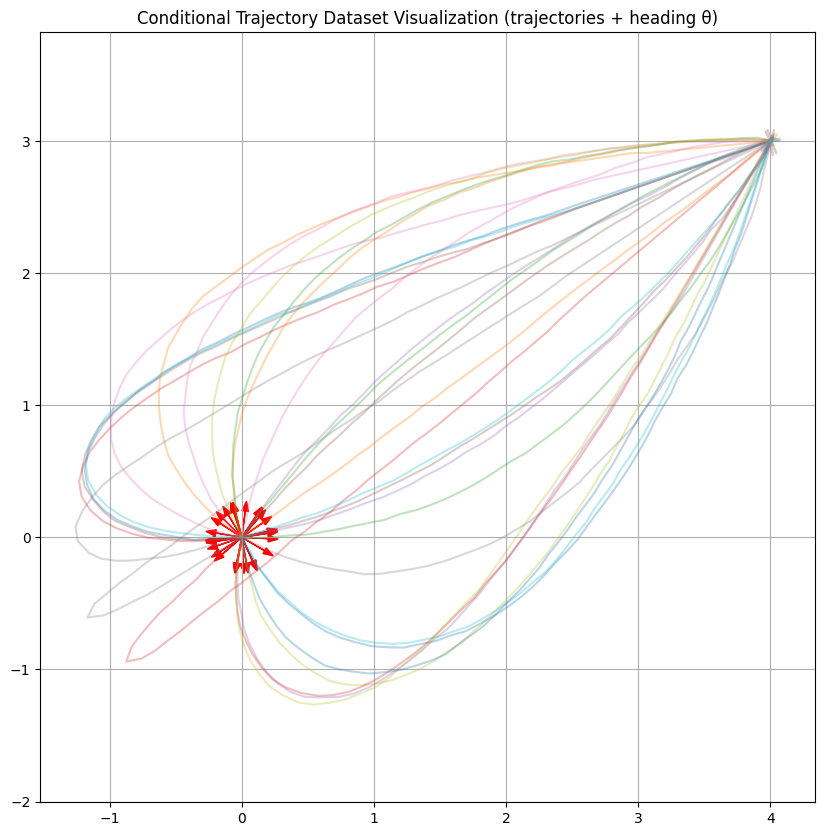

In [7]:
visualize_conditional_dataset(trajectories, thetas, num_display=30)


In [8]:
# ========== Cell 1: Dataset + Model (cond=(cosθ,sinθ)) + DataLoader ==========

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 假设你前面已经生成了 trajectories, thetas：
# trajectories.shape == (N, 2, T), thetas.shape == (N,)
print("trajectories.shape:", trajectories.shape)
print("thetas.shape:", thetas.shape)

UNET_T = trajectories.shape[2]   # 轨迹长度 T
print("UNET_T =", UNET_T)


# -------- 1) Dataset：输出 (traj, cond_vec) 其中 cond_vec = (cosθ, sinθ) --------
class TrajectoryAngleCondDataset(Dataset):
    def __init__(self, trajectories: np.ndarray, thetas: np.ndarray):
        """
        trajectories: (N, 2, T)
        thetas:       (N,)  每条轨迹一个 heading angle（弧度）
        """
        assert len(trajectories) == len(thetas)
        self.trajectories = trajectories.astype(np.float32)
        self.thetas = thetas.astype(np.float32)
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        traj = torch.from_numpy(self.trajectories[idx])   # (2, T)
        theta = self.thetas[idx]
        cond_vec = torch.tensor(
            [np.cos(theta), np.sin(theta)],
            dtype=torch.float32
        )  # (2,)
        return traj, cond_vec


dataset = TrajectoryAngleCondDataset(trajectories, thetas)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)
print("Dataset size:", len(dataset))


# -------- 2) 条件版 SimpleUNet1D：cond_dim=2 (cosθ, sinθ) --------
# 假设 SinusoidalPosEmb, Mish, ResBlock1D 已经在上面定义好
class SimpleUNet1D(nn.Module):
    def __init__(self, time_emb_dim: int = 128, hidden_dim: int = 128, cond_dim: int = 0):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # 时间编码 MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # 条件编码
        if cond_dim > 0:
            self.cond_mlp = nn.Sequential(
                nn.Linear(cond_dim, time_emb_dim * 4),
                Mish(),
                nn.Linear(time_emb_dim * 4, time_emb_dim)
            )
        else:
            self.cond_mlp = None
        
        # 输入层：2 通道 (x, y)
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        # 编码器
        self.down1_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        self.down2_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        # 中间层
        self.mid_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        
        # 解码器
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # 输出层
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, hidden_dim),
            Mish(),
            nn.Conv1d(hidden_dim, 2, 3, padding=1)
        )
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor = None) -> torch.Tensor:
        """
        x:    (B, 2, T)
        t:    (B,) or (B,1)
        cond: (B, cond_dim)
        """
        # 时间编码
        t_emb = self.time_mlp(t)   # (B, time_emb_dim)
        
        # 条件编码 + 融合
        if self.cond_mlp is not None and cond is not None:
            if cond.dim() == 1:
                cond = cond.unsqueeze(0)
            if cond.shape[0] != x.shape[0]:
                cond = cond.expand(x.shape[0], -1)
            cond_emb = self.cond_mlp(cond)       # (B, time_emb_dim)
            t_emb = t_emb + cond_emb
        
        # 输入卷积
        h = self.conv_in(x)  # (B, hidden_dim, T)
        
        # -------- 编码器 --------
        h1 = h
        for block in self.down1_block:
            h1 = block(h1, t_emb)
        h1_pooled = self.down1_sample(h1)  # (B, hidden_dim, T1)
        
        h2 = h1_pooled
        for block in self.down2_block:
            h2 = block(h2, t_emb)
        h2_pooled = self.down2_sample(h2)  # (B, hidden_dim, T2)
        
        # -------- 中间层 --------
        h_mid = h2_pooled
        for block in self.mid_block:
            h_mid = block(h_mid, t_emb)
        
        # -------- 解码器 up2 --------
        h_up2 = self.up2_sample(h_mid)     # (B, hidden_dim, T2_up)
        # 🔴 对齐时间长度：裁成一样长
        if h_up2.shape[2] != h2.shape[2]:
            min_len = min(h_up2.shape[2], h2.shape[2])
            h_up2 = h_up2[:, :, :min_len]
            h2_aligned = h2[:, :, :min_len]
        else:
            h2_aligned = h2
        
        h = torch.cat([h_up2, h2_aligned], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)              # (B, hidden_dim, T2_up_aligned)
        
        # -------- 解码器 up1 --------
        h_up1 = self.up1_sample(h)        # (B, hidden_dim, T1_up)
        if h_up1.shape[2] != h1.shape[2]:
            min_len = min(h_up1.shape[2], h1.shape[2])
            h_up1 = h_up1[:, :, :min_len]
            h1_aligned = h1[:, :, :min_len]
        else:
            h1_aligned = h1
        
        h = torch.cat([h_up1, h1_aligned], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)              # (B, hidden_dim, T_final)
        
        out = self.conv_out(h)            # (B, 2, T_final)
        return out



# -------- 3) 实例化模型 & optimizer --------
model = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=2,      # (cosθ, sinθ)
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("✅ Model & optimizer ready.")


Using device: cuda
trajectories.shape: (1000, 2, 50)
thetas.shape: (1000,)
UNET_T = 50
Dataset size: 1000
✅ Model & optimizer ready.


In [9]:
# ========== Cell 2: Flow Matching 训练循环 (linear path, v* = y - z) ==========

import math
from tqdm.auto import tqdm

EPOCHS = 50

model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    num_batches = 0
    
    for traj_batch, cond_batch in dataloader:
        # traj_batch: (B, 2, T), cond_batch: (B, 2)
        y = traj_batch.to(device)          # 真实轨迹
        cond = cond_batch.to(device)       # (cosθ, sinθ)
        B = y.shape[0]

        # 1) 采样时间 t ~ Uniform[0,1]
        t = torch.rand(B, device=device)   # (B,)

        # 2) 采样噪声轨迹 z ~ N(0,I)
        z = torch.randn_like(y)            # (B, 2, T)

        # 3) 构造中间状态 x_t = (1-t) z + t y
        t_ = t.view(B, 1, 1)               # (B,1,1)
        x_t = (1.0 - t_) * z + t_ * y      # (B,2,T)

        # 4) 解析最优速度场 v* = y - z
        v_target = y - z                   # (B,2,T)

        # 5) 模型预测 v_pred(x_t, t, cond)
        v_pred = model(x_t, t, cond=cond)  # (B,2,T)

        loss = ((v_pred - v_target) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1
    
    avg_loss = running_loss / max(num_batches, 1)
    print(f"[Epoch {epoch:03d}] FM train loss = {avg_loss:.6f}")
    
print("✅ Training finished.")


c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Epoch 001] FM train loss = 1.414310
[Epoch 002] FM train loss = 0.451821
[Epoch 003] FM train loss = 0.274125
[Epoch 004] FM train loss = 0.207437
[Epoch 005] FM train loss = 0.155457
[Epoch 006] FM train loss = 0.127989
[Epoch 007] FM train loss = 0.116162
[Epoch 008] FM train loss = 0.096374
[Epoch 009] FM train loss = 0.091743
[Epoch 010] FM train loss = 0.098909
[Epoch 011] FM train loss = 0.094366
[Epoch 012] FM train loss = 0.079531
[Epoch 013] FM train loss = 0.095772
[Epoch 014] FM train loss = 0.080897
[Epoch 015] FM train loss = 0.083282
[Epoch 016] FM train loss = 0.085396
[Epoch 017] FM train loss = 0.082063
[Epoch 018] FM train loss = 0.065012
[Epoch 019] FM train loss = 0.065995
[Epoch 020] FM train loss = 0.069835
[Epoch 021] FM train loss = 0.072031
[Epoch 022] FM train loss = 0.056593
[Epoch 023] FM train loss = 0.052551
[Epoch 024] FM train loss = 0.063396
[Epoch 025] FM train loss = 0.054451
[Epoch 026] FM train loss = 0.067609
[Epoch 027] FM train loss = 0.058338
[

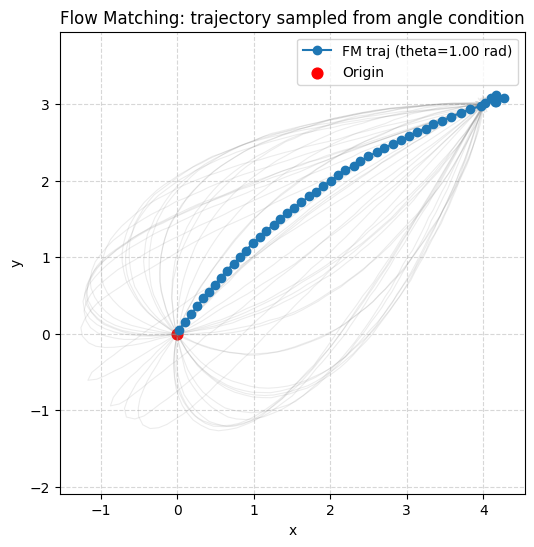

In [11]:
# ========== Cell 3: 从角度 θ 采样整条轨迹 + 可视化 ==========

import matplotlib.pyplot as plt

@torch.no_grad()
def sample_traj_from_theta(
    model,
    theta: float,
    T_traj: int = None,
    n_steps: int = 50,
    device: str = "cpu",
):
    """
    从噪声轨迹出发，用 Flow Matching (linear path) 从 t=0 积分到 t=1，
    在条件 = (cosθ, sinθ) 下生成一条未来轨迹。
    """
    model.eval()
    if T_traj is None:
        T_traj = UNET_T   # 默认用训练时的长度

    # 条件向量 (cosθ, sinθ)
    cond = torch.tensor(
        [[np.cos(theta), np.sin(theta)]],
        dtype=torch.float32,
        device=device,
    )  # (1,2)

    # 初始噪声轨迹 x(0)
    x = torch.randn(1, 2, T_traj, device=device)  # (1,2,T)

    # 时间网格 0→1
    t_vals = torch.linspace(0., 1., n_steps + 1, device=device)

    for i in range(n_steps):
        t = t_vals[i].view(1)                 # (1,)
        v = model(x, t, cond=cond)            # (1,2,T)
        dt = float(t_vals[i+1] - t_vals[i])
        x = x + dt * v                        # Euler 积分

    traj = x[0].detach().cpu().numpy()        # (2,T)
    return traj


def plot_sampled_traj_for_theta(theta: float, num_train_show: int = 50):
    """
    画出：
      - 一部分训练集的直线轨迹（参考）
      - Flow Matching 在角度 θ 下采样出的整条轨迹
    """
    # 1) 采样
    traj_fm = sample_traj_from_theta(
        model=model,
        theta=theta,
        T_traj=UNET_T,
        n_steps=50,
        device=device,
    )  # (2,T)

    # 2) 画图
    plt.figure(figsize=(6, 6))

    # 训练数据中画一些射线当背景
    N_show = min(num_train_show, trajectories.shape[0])
    for i in range(N_show):
        plt.plot(
            trajectories[i, 0, :],
            trajectories[i, 1, :],
            alpha=0.15,
            linewidth=0.8,
            color="gray",
        )

    # FM 生成的轨迹
    plt.plot(
        traj_fm[0, :],
        traj_fm[1, :],
        "-o",
        label=f"FM traj (theta={theta:.2f} rad)",
    )

    # 原点
    plt.scatter([0.0], [0.0], c="red", s=60, label="Origin")

    plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.title("Flow Matching: trajectory sampled from angle condition")
    plt.show()


# 🌟 Demo：随便选一个角度，比如 0.5 rad
theta_demo = 1
plot_sampled_traj_for_theta(theta_demo)


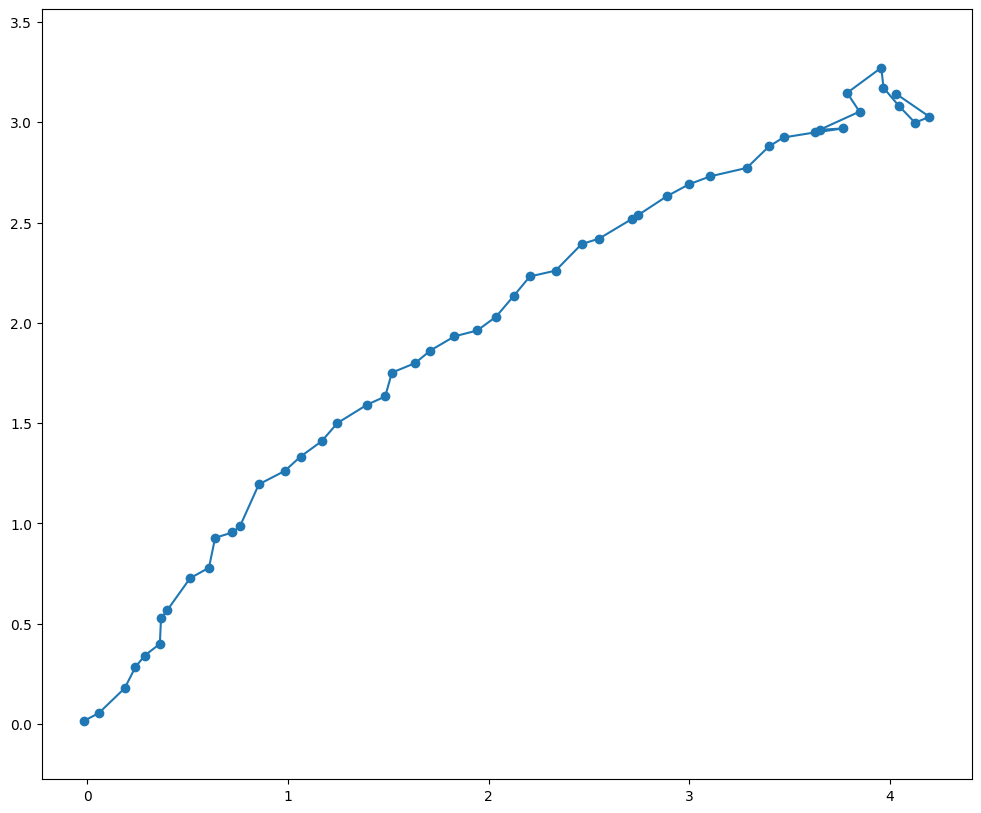

In [12]:
theta = 1.0
cond_vec = torch.tensor([[np.cos(theta), np.sin(theta)]], dtype=torch.float32)

# 初始化噪声轨迹 (1,2,T)
x_init = torch.randn(1, 2, UNET_T)

solver = ODESolver(
    model=model,
    traj_len=UNET_T,
    T_final=1.0,
    use_cbf=False,          # 先关掉 CBF，测试 FM 是否正常
    cond_vec=cond_vec,      # ★★ 关键
)

x_T = solver.sample(x_init)
traj_fm = x_T[0].cpu().numpy()

plt.plot(traj_fm[0], traj_fm[1], '-o')
plt.axis("equal")
plt.show()


In [13]:
# ===============================================================
# CBF 投影（世界坐标）：整条轨迹版本 + 单步 wrapper
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # 允许形状 (1,2,N) 或 (2,N)
    agent_safe_radius: float = 0.5,
    # ★ 压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标，整条轨迹版本）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹（A 车位置）
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物列表（可以为 [] 或 None）
      - other_agent_traj:
            - (1,2,N) 或 (2,N)，另一辆车的整条轨迹（B 车）
    输出:
      - v_safe_1x2N: (1,2,N) 投影后的安全速度
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    # 允许 x_1x2N 传入 (2,N)，统一成 (1,2,N)
    if x_1x2N.dim() == 2:
        x_1x2N = x_1x2N.unsqueeze(0)
    B, D, N = x_1x2N.shape
    assert D == 2, "x_1x2N 的 shape 必须是 (B,2,N) 或 (2,N)"

    # v_nom 同样统一维度
    if v_nom_1x2N.dim() == 2:
        v_nom_1x2N = v_nom_1x2N.unsqueeze(0)

    # 为了简单，我们目前只支持 B=1 的单条轨迹
    assert B == 1, "当前实现假定 batch=1（单条轨迹），如果需要批量可再扩展"

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        # 支持 (1,2,N) 或 (2,N)
        if other_agent_traj.dim() == 3:
            x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        elif other_agent_traj.dim() == 2:
            x_other_2N = other_agent_traj             # (2,N)
        else:
            raise ValueError("other_agent_traj 形状必须是 (1,2,N) 或 (2,N)")

        # delta_agent: (N,2) = x_A - x_B
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)                  # (N,)
        P = press_k / dist.pow(press_n)                                        # (N,)
    else:
        delta_agent = None
        dist = None
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环（多次迭代 refine）
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                # 你之前定义好的函数：ellipse_h_grad_batch(x, e)
                # 返回:
                #   h_e:   (N,)
                #   grad_w:(N,2)
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)
                h_eff = h_e - float(extra_margin)          # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                  # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h  # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # 注意：delta_agent 和 dist 在上面已经算过
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2      # (N,)
            grad_agent = 2.0 * delta_agent                # (N,2)

            alpha_h_agent = gamma_x * h_agent             # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


# ===============================================================
# 单步版本 wrapper：方便在 rollout 的 for k in range(T) 里调用
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_step(
    x_now_2: torch.Tensor,          # (2,)  当前 A 车位置
    v_nom_2: torch.Tensor,          # (2,)  名义速度
    ellipses,
    other_agent_pos_2: torch.Tensor = None,  # (2,) 当前 B 车位置
    agent_safe_radius: float = 0.5,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    单步 CBF 投影，专为在线仿真准备：
      输入单个时刻的 x_A, v_nom, x_B
      内部自动扩展成 (1,2,1)，调用上面的 cbf_project_velocity_world。
    """
    device = x_now_2.device
    x_traj = x_now_2.view(1, 2, 1)      # (1,2,1)
    v_traj = v_nom_2.view(1, 2, 1)      # (1,2,1)

    if other_agent_pos_2 is not None:
        other_traj = other_agent_pos_2.view(1, 2, 1)   # (1,2,1)
    else:
        other_traj = None

    v_safe_traj = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses,
        extra_margin=extra_margin,
        max_corr_norm=max_corr_norm,
        passes=5,
        other_agent_traj=other_traj,
        agent_safe_radius=agent_safe_radius,
        gamma_min=gamma_min,
        w_p=w_p,
        press_k=press_k,
        press_n=press_n,
    )  # (1,2,1)

    v_safe_2 = v_safe_traj.squeeze(0).squeeze(-1)  # (2,)
    return v_safe_2


In [14]:
import numpy as np
import torch
import math

device = "cuda" if torch.cuda.is_available() else "cpu"


In [15]:
def wrap_to_pi(angle: torch.Tensor) -> torch.Tensor:
    return (angle + math.pi) % (2 * math.pi) - math.pi

def compute_theta_sincos_to_goal(x_self, x_goal, device=None):
    """
    从 x_self 指向 x_goal 的角度 θ，输出 cond 向量 [cosθ, sinθ]
    x_self, x_goal: (2,)
    返回: np.ndarray, shape = (2,)
    """
    if device is None:
        if isinstance(x_self, torch.Tensor):
            device = x_self.device
        else:
            device = "cpu"

    x_self = torch.as_tensor(x_self, dtype=torch.float32, device=device).view(2)
    x_goal = torch.as_tensor(x_goal, dtype=torch.float32, device=device).view(2)

    vec_goal = x_goal - x_self
    theta = torch.atan2(vec_goal[1], vec_goal[0])
    theta = wrap_to_pi(theta)

    theta_val = float(theta.item())
    return np.array([math.cos(theta_val), math.sin(theta_val)], dtype=np.float32)


In [16]:
@torch.no_grad()
def query_local_velocity_from_unet(
    model,
    x_self: torch.Tensor,      # (2,)
    t_scalar: float,           # ∈ [0,1]
    cond_vec: np.ndarray,      # ⭐ shape = (2,) = [cosθ, sinθ]
    N_train: int = 100,
    device: str = "cpu",
):
    """
    用已经训练好的 angle-conditional UNet，在当前点 x_self 上查询局部速度。

    假设训练时:
      - 输入轨迹 x ∈ R^{B×2×T}
      - 条件 cond ∈ R^{B×2} = [cosθ, sinθ]
    """
    x_self = x_self.to(device)

    # 伪轨迹 (1,2,N_train)
    x_in = x_self.view(1, 2, 1).repeat(1, 1, N_train)

    # 时间 (1,)
    t_tensor = torch.tensor([t_scalar], dtype=torch.float32, device=device)

    # 条件 (1,2)
    cond = torch.tensor(cond_vec.reshape(1, 2), dtype=torch.float32, device=device)

    v_pred = model(x_in, t_tensor, cond=cond)  # (1,2,N_train)
    v_local = v_pred[0, :, -1]                 # (2,)
    return v_local


In [17]:
@torch.no_grad()
def make_goal_pulled_v_nom(
    xA_tensor: torch.Tensor,   # (2,)
    t_norm: float,
    model,
    goal_A: np.ndarray,
    cond_vec_A: np.ndarray,    # ⭐ [cosθ, sinθ]
    kg: float = 0.8,
    lam: float = 0.3,
):
    """
    v_nom = (1 - lam) * v_FM(cond_vec) + lam * v_goal
    """
    # 1) FM 速度（带角度条件）
    v_fm = query_local_velocity_from_unet(
        model=model,
        x_self=xA_tensor,
        t_scalar=t_norm,
        cond_vec=cond_vec_A,   # ⭐ 用 [cosθ, sinθ]
        N_train=100,
        device=device,
    )  # (2,)
    
    # 2) 朝 goal 的速度
    xA_np = xA_tensor.detach().cpu().numpy()
    dir_goal = goal_A - xA_np
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal < 1e-6:
        v_goal_np = np.zeros(2, dtype=np.float32)
    else:
        v_goal_np = kg * dir_goal / dist_goal

    v_goal = torch.tensor(v_goal_np, dtype=torch.float32, device=device)

    # 3) 线性组合
    v_nom = (1.0 - lam) * v_fm + lam * v_goal
    return v_nom


In [28]:
import numpy as np

# 仿真参数
dt = 0.05          # 步长
T_sim = 8.0        # 总时间
N_steps = int(T_sim / dt)

# A / B 车的初始位置 & 目标
xA_0 = np.array([-1.0, -1.0], dtype=np.float32)
xB_0 = np.array([-1.0,  1.0], dtype=np.float32)

goal_A = np.array([1.0, 1.0], dtype=np.float32)
goal_B = np.array([1.0, -1.0], dtype=np.float32)

safe_radius = 0.3   # 碰撞安全半径
v_max = 0.5         # A 车最大速度

def simple_goal_controller(x, goal, v_max=0.4):
    """
    一个给 B 车用的简单 controller：朝着 goal 走。
    """
    direction = goal - x
    dist = np.linalg.norm(direction)
    if dist < 1e-6:
        return np.zeros(2, dtype=np.float32)
    v = direction / dist * min(v_max, dist)
    return v.astype(np.float32)


In [29]:
goal_stop_A = 0.08   # A 车停止半径
goal_stop_B = 0.08   # B 车停止半径
safe_radius = 0.3

def mpc_step_A_goal_cbf_angle(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    ellipses=None,
):
    # ---- B 车：自己判断是否该停 ----
    dist_goal_B = np.linalg.norm(xB - goal_B)
    if dist_goal_B < goal_stop_B:
        vB = np.zeros(2, dtype=np.float32)
    else:
        vB = simple_goal_controller(xB, goal_B, v_max=0.4)

    # ---- A 车：如果已经很接近 goal_A，就停住，但 B 仍然可以继续走 ----
    dist_goal_A = np.linalg.norm(xA - goal_A)
    if dist_goal_A < goal_stop_A:
        vA_safe = np.zeros(2, dtype=np.float32)

        # 还是要把位置往前推进一下（B 还走，A 不走）
        xA_next = xA + vA_safe * dt
        xB_next = xB + vB      * dt
        return xA_next, xB_next, vA_safe, vB

    # ========= 以下是“正常 A 车规划 + CBF”部分 =========

    # ⭐ A 车：条件向量 [cosθ, sinθ]，θ = 从 A 指向 goal_A 的角度
    cond_vec_A = compute_theta_sincos_to_goal(xA, goal_A, device=device)

    # A 车：FM + goal 的名义速度
    xA_tensor = torch.tensor(xA, dtype=torch.float32, device=device)
    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        cond_vec_A=cond_vec_A,
        kg=0.8,
        lam=0.3,
    )

    # A 车：CBF 投影
    xB_tensor = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=1.0,
        gamma_min=1.0,
        w_p=1.0,
        press_k=1.0,
        press_n=2.0,
    )

    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # 欧拉更新
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB      * dt

    return xA_next, xB_next, vA_safe, vB


In [41]:
dt = 0.05
T_sim = 80.0
N_steps = int(T_sim / dt)

xA_0 = np.array([0.0,  0.0], dtype=np.float32)
xB_0 = np.array([0.0, 3.0], dtype=np.float32)
goal_A = np.array([4.0, 3.0], dtype=np.float32)
goal_B = np.array([4.0,  0.0], dtype=np.float32)

xA = xA_0.copy()
xB = xB_0.copy()

xs_A = [xA.copy()]
xs_B = [xB.copy()]
vs_A = []
vs_B = []

goal_tol = 0.05   # 把这个当作“画图用的终点精度”

for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)   # t ∈ [0,1]

    xA, xB, vA_safe, vB = mpc_step_A_goal_cbf_angle(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=None,
    )

    xs_A.append(xA.copy())
    xs_B.append(xB.copy())
    vs_A.append(vA_safe.copy())
    vs_B.append(vB.copy())

    # ⭐ 到达目标附近就结束仿真（避免多余的后半段时间轴）
    if np.linalg.norm(xA - goal_A) < goal_tol:
        print(f"Agent A reached goal at step {k}")
        break

xs_A = np.stack(xs_A, axis=0)
xs_B = np.stack(xs_B, axis=0)


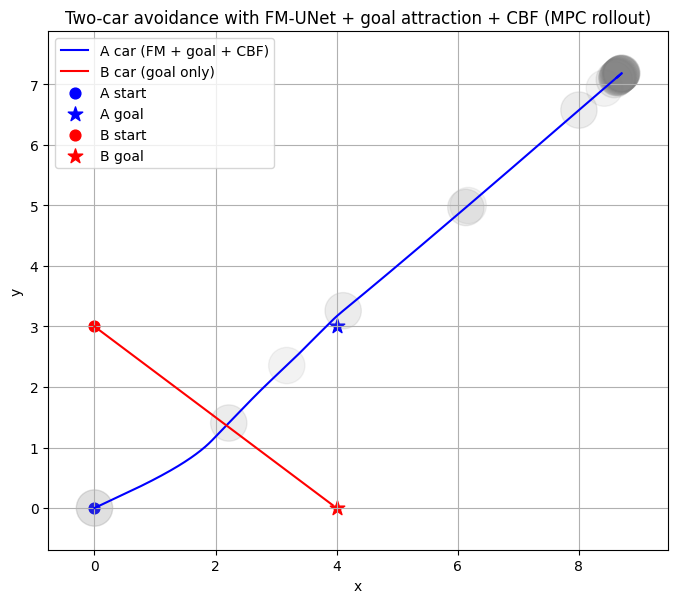

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

# ===== 轨迹 =====
ax.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + goal + CBF)')
ax.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (goal only)')

# ===== 起点 / 终点 =====
ax.scatter(xA_0[0], xA_0[1], c='b', marker='o', s=60, label='A start')
ax.scatter(goal_A[0], goal_A[1], c='b', marker='*', s=120, label='A goal')

ax.scatter(xB_0[0], xB_0[1], c='r', marker='o', s=60, label='B start')
ax.scatter(goal_B[0], goal_B[1], c='r', marker='*', s=120, label='B goal')

# ===== A 车的安全圈（灰色半透明） =====
# 每隔若干步画一个圈，防止太密
step = max(1, len(xs_A) // 15)   # 可以调 10 / 20 来控制圈的数量

for i in range(0, len(xs_A), step):
    circle_A = plt.Circle(
        (xs_A[i, 0], xs_A[i, 1]),
        safe_radius,
        color='gray',
        alpha=0.15,
        fill=True
    )
    ax.add_patch(circle_A)

# A 车的安全圈
for i in range(0, len(xs_A), max(1, len(xs_A)//10)):
    circle = plt.Circle(xs_A[i], safe_radius, color='gray', alpha=0.1)
    plt.gca().add_patch(circle)


# ===== 画面设置 =====
ax.set_aspect('equal', 'box')
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Two-car avoidance with FM-UNet + goal attraction + CBF (MPC rollout)")
ax.legend(loc='best')

plt.show()


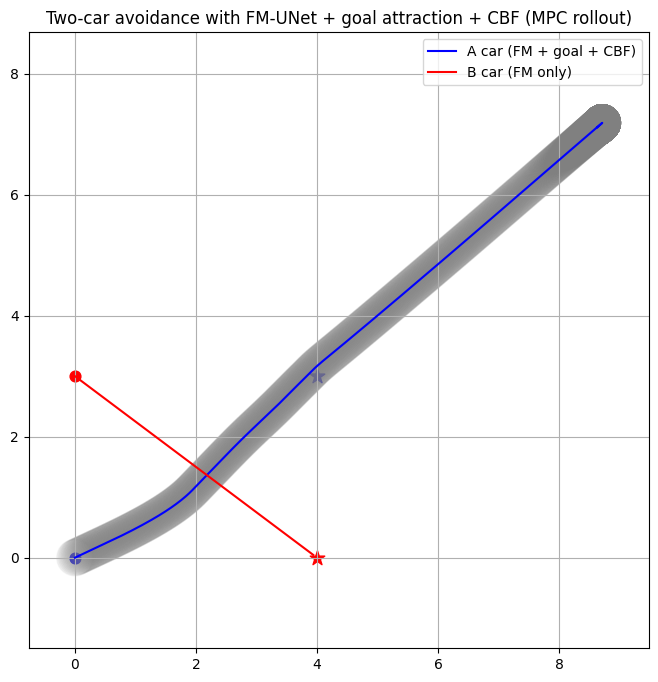

In [43]:
plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + goal + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM only)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o', s=60)
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*', s=120)

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o', s=60)
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*', s=120)

# ===== A 车安全圈（连续阴影） =====
for i in range(len(xs_A)):
    circle = plt.Circle(
        (xs_A[i, 0], xs_A[i, 1]),
        safe_radius,
        color='gray',
        alpha=0.08,
        edgecolor=None
    )
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with FM-UNet + goal attraction + CBF (MPC rollout)")
plt.show()


In [50]:
goal_stop_A = 0.05   # A 车判定“到达目标”的半径，可以自己调
goal_stop_B = 0.05   #（如果你也想让 B 停的话）

def mpc_step_A_goal_cbf_angle(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    ellipses=None,
):
    # -------- 0) A 已经到 goal？直接停住 --------
    dist_goal_A = np.linalg.norm(xA - goal_A)
    if dist_goal_A < goal_stop_A:
        # A 不再移动
        vA_safe = np.zeros(2, dtype=np.float32)

        # B 你可以选择继续走 / 也停，这里先让 B 继续（用 simple_goal_controller 举例）
        dist_goal_B = np.linalg.norm(xB - goal_B)
        if dist_goal_B < goal_stop_B:
            vB = np.zeros(2, dtype=np.float32)
        else:
            vB = simple_goal_controller(xB, goal_B, v_max=0.4)

        xA_next = xA             # A 就保持在原地
        xB_next = xB + vB * dt   # B 正常往前走一步
        return xA_next, xB_next, vA_safe, vB

    # -------- 1) B 车：你现在用的是 FM only/goal only，看你版本 --------
    dist_goal_B = np.linalg.norm(xB - goal_B)
    if dist_goal_B < goal_stop_B:
        vB = np.zeros(2, dtype=np.float32)
    else:
        vB = simple_goal_controller(xB, goal_B, v_max=0.4)
        # 或者用你那套 FM+goal 的 vB 也行

    # -------- 2) A 车：FM + goal 得到名义速度 --------
    cond_vec_A = compute_theta_sincos_to_goal(xA, goal_A, device=device)
    xA_tensor  = torch.tensor(xA, dtype=torch.float32, device=device)

    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        cond_vec_A=cond_vec_A,
        kg=0.8,
        lam=0.3,
    )

    # -------- 3) A 车：CBF 投影 --------
    xB_tensor_for_cbf = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor_for_cbf,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=1.0,
        gamma_min=1.0,
        w_p=1.0,
        press_k=1.0,
        press_n=2.0,
    )
    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # -------- 4) 欧拉更新 --------
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB      * dt

    return xA_next, xB_next, vA_safe, vB


In [54]:
goal_tol_A = 0.2   # 大一点，比如 0.2，看情况再调
goal_tol_B = 0.2

xA_0 = np.array([0.0,  0.0], dtype=np.float32)
xB_0 = np.array([0.0, 3.0], dtype=np.float32)
goal_A = np.array([4.0, 3.0], dtype=np.float32)
goal_B = np.array([4.0,  0.0], dtype=np.float32)

xA = xA_0.copy()
xB = xB_0.copy()

xs_A = [xA.copy()]
xs_B = [xB.copy()]
vs_A = []
vs_B = []

for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)

    # 先正常用 FM + goal + CBF 算下一步
    xA, xB, vA_safe, vB = mpc_step_A_goal_cbf_angle(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=None,
    )

    # ===== 在这里检查 A 是否到达 goal =====
    distA = np.linalg.norm(xA - goal_A)
    if distA < goal_tol_A:
        print(f"[INFO] A reached goal at step {k}, dist = {distA:.3f}")
        # 把 A 强制钉死在 goal 上，速度为 0
        xA = goal_A.copy()
        vA_safe = np.zeros(2, dtype=np.float32)

        xs_A.append(xA.copy())
        xs_B.append(xB.copy())
        vs_A.append(vA_safe.copy())
        vs_B.append(vB.copy())
        break  # ⭐ 直接退出循环，不再往右上角飞

    # 如果还没到，就正常记录
    xs_A.append(xA.copy())
    xs_B.append(xB.copy())
    vs_A.append(vA_safe.copy())
    vs_B.append(vB.copy())

xs_A = np.stack(xs_A, axis=0)
xs_B = np.stack(xs_B, axis=0)


[INFO] A reached goal at step 29, dist = 0.173


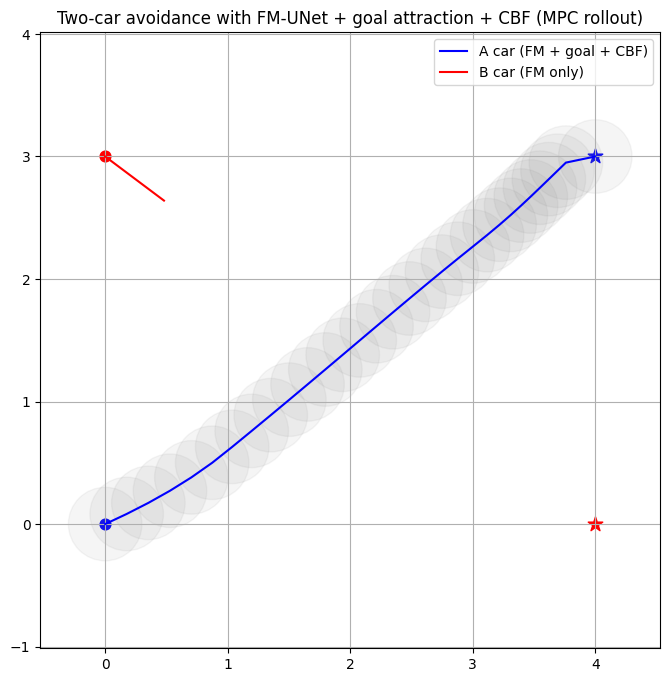

In [55]:
plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + goal + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM only)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o', s=60)
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*', s=120)

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o', s=60)
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*', s=120)

# ===== A 车安全圈（连续阴影） =====
for i in range(len(xs_A)):
    circle = plt.Circle(
        (xs_A[i, 0], xs_A[i, 1]),
        safe_radius,
        color='gray',
        alpha=0.08,
        edgecolor=None
    )
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with FM-UNet + goal attraction + CBF (MPC rollout)")
plt.show()


In [60]:
goal_tol_A = 0.2   # A 判定到达目标的半径
goal_tol_B = 0.2   # B 判定到达目标的半径

xA_0 = np.array([0.0,  0.0], dtype=np.float32)
xB_0 = np.array([0.0, 3.0], dtype=np.float32)
goal_A = np.array([4.0, 3.0], dtype=np.float32)
goal_B = np.array([4.0, 0.0], dtype=np.float32)

xA = xA_0.copy()
xB = xB_0.copy()

xs_A = [xA.copy()]
xs_B = [xB.copy()]
vs_A = []
vs_B = []

# ================== Phase 1：A + B 一起跑 ==================
for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)

    # 先正常用 FM + goal + CBF 算下一步
    xA, xB, vA_safe, vB = mpc_step_A_goal_cbf_angle(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=None,
    )

    # 记录轨迹
    xs_A.append(xA.copy())
    xs_B.append(xB.copy())
    vs_A.append(vA_safe.copy())
    vs_B.append(vB.copy())

    # ===== 在这里检查 A 是否到达 goal =====
    distA = np.linalg.norm(xA - goal_A)
    if distA < goal_tol_A:
        print(f"[INFO] A reached goal at step {k}, dist = {distA:.3f}")
        # 把 A 钉死在 goal 上
        xA = goal_A.copy()
        xs_A[-1] = xA.copy()
        vs_A[-1] = np.zeros(2, dtype=np.float32)
        break  # 结束 Phase 1

# 记录此时的 A、B 状态
xA_final = xs_A[-1].copy()
xB_final = xs_B[-1].copy()
xB = xB_final.copy()

# ================== Phase 2：只让 B 继续跑到自己的 goal_B ==================
for k2 in range(N_steps):
    distB = np.linalg.norm(xB - goal_B)
    if distB < goal_tol_B:
        print(f"[INFO] B reached goal in phase 2, dist = {distB:.3f}")
        xB = goal_B.copy()
        vB = np.zeros(2, dtype=np.float32)

        # A 保持不动，B 停在 goal_B
        xs_A.append(xA_final.copy())
        xs_B.append(xB.copy())
        vs_A.append(np.zeros(2, dtype=np.float32))
        vs_B.append(vB.copy())
        break

    # ⭐ 这里给 B 一个简单的朝 goal_B 走的控制器
    # 如果你想用 FM+goal，也可以在这里换成你自己的 vB_nom 逻辑
    vB = simple_goal_controller(xB, goal_B, v_max=0.4)
    xB = xB + vB * dt

    # A 保持在终点不动
    xs_A.append(xA_final.copy())
    xs_B.append(xB.copy())
    vs_A.append(np.zeros(2, dtype=np.float32))
    vs_B.append(vB.copy())

# ================== 转成 numpy 方便画图 ==================
xs_A = np.stack(xs_A, axis=0)
xs_B = np.stack(xs_B, axis=0)


[INFO] A reached goal at step 29, dist = 0.173
[INFO] B reached goal in phase 2, dist = 0.195


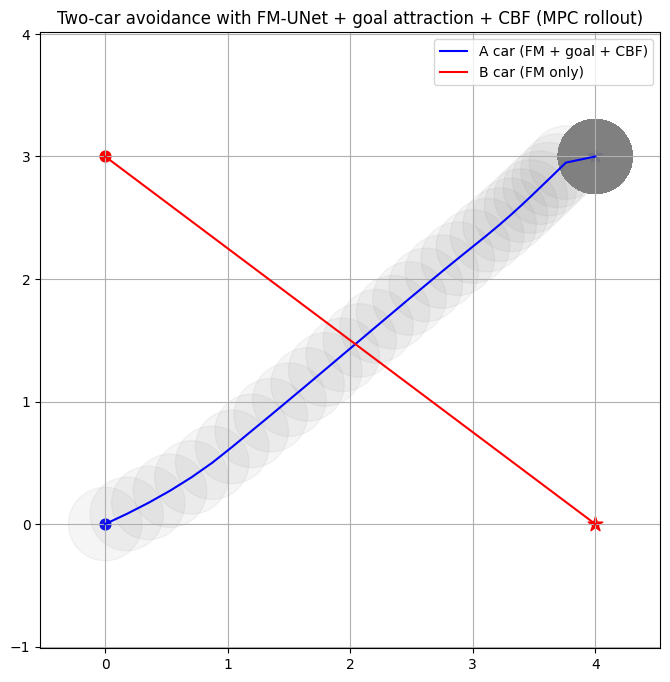

In [61]:
plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + goal + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM only)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o', s=60)
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*', s=120)

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o', s=60)
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*', s=120)

# ===== A 车安全圈（连续阴影） =====
for i in range(len(xs_A)):
    circle = plt.Circle(
        (xs_A[i, 0], xs_A[i, 1]),
        safe_radius,
        color='gray',
        alpha=0.08,
        edgecolor=None
    )
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with FM-UNet + goal attraction + CBF (MPC rollout)")
plt.show()


In [44]:
@torch.no_grad()
def make_goal_pulled_v_nom(
    xA_tensor: torch.Tensor,   # (2,)
    t_norm: float,
    model,
    goal_A: np.ndarray,
    cond_vec_A: np.ndarray,    # [cosθ, sinθ]
    kg: float = 0.8,
    lam: float = 0.3,
):
    """
    v_nom = (1 - lam) * v_FM(cond_vec) + lam * v_goal
    """
    # 1) FM 速度
    v_fm = query_local_velocity_from_unet(
        model=model,
        x_self=xA_tensor,
        t_scalar=t_norm,
        cond_vec=cond_vec_A,
        N_train=100,
        device=device,
    )  # (2,)

    # 2) 朝 goal 的速度（随距离变小）
    xA_np = xA_tensor.detach().cpu().numpy()
    dir_goal = goal_A - xA_np
    dist_goal = np.linalg.norm(dir_goal)
    if dist_goal < 1e-6:
        v_goal_np = np.zeros(2, dtype=np.float32)
    else:
        v_goal_np = kg * dir_goal      # 注意：不再除以 dist_goal

    v_goal = torch.tensor(v_goal_np, dtype=torch.float32, device=device)

    # 3) 线性组合
    v_nom = (1.0 - lam) * v_fm + lam * v_goal
    return v_nom


In [45]:
safe_radius  = 0.3
goal_stop_A  = 0.08
goal_stop_B  = 0.08

def mpc_step_A_goal_cbf_angle(
    xA: np.ndarray,
    xB: np.ndarray,
    t_norm: float,
    model,
    goal_A: np.ndarray,
    goal_B: np.ndarray,
    ellipses=None,
):
    # -------- B 车：FM + goal（不加 CBF） --------
    dist_goal_B = np.linalg.norm(xB - goal_B)
    if dist_goal_B < goal_stop_B:
        vB = np.zeros(2, dtype=np.float32)
    else:
        cond_vec_B = compute_theta_sincos_to_goal(xB, goal_B, device=device)
        xB_tensor  = torch.tensor(xB, dtype=torch.float32, device=device)
        vB_nom_tensor = make_goal_pulled_v_nom(
            xA_tensor=xB_tensor,     # ⭐ 名字仍叫 xA_tensor
            t_norm=t_norm,
            model=model,
            goal_A=goal_B,           # ⭐ 对 B 来说，它的 goal_B 作为 goal_A 传入
            cond_vec_A=cond_vec_B,   # ⭐ 同理，cond_vec_B 作为 cond_vec_A
            kg=0.8,
            lam=0.3,
        )
        vB = vB_nom_tensor.detach().cpu().numpy()

    # -------- A 车：如果接近 goal_A，就停住 --------
    dist_goal_A = np.linalg.norm(xA - goal_A)
    if dist_goal_A < goal_stop_A:
        vA_safe = np.zeros(2, dtype=np.float32)
        xA_next = xA + vA_safe * dt
        xB_next = xB + vB      * dt
        return xA_next, xB_next, vA_safe, vB

    # -------- A 车：FM + goal 的名义速度 --------
    cond_vec_A = compute_theta_sincos_to_goal(xA, goal_A, device=device)
    xA_tensor  = torch.tensor(xA, dtype=torch.float32, device=device)
    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        cond_vec_A=cond_vec_A,
        kg=0.8,
        lam=0.3,
    )

    # -------- A 车：CBF 投影，避开 B --------
    xB_tensor_for_cbf = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor_for_cbf,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=1.0,
        gamma_min=1.0,
        w_p=1.0,
        press_k=1.0,
        press_n=2.0,
    )
    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # -------- 欧拉更新 --------
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB      * dt

    return xA_next, xB_next, vA_safe, vB


In [46]:
dt = 0.05
T_sim = 80.0
N_steps = int(T_sim / dt)

xA_0 = np.array([0.0,  1.0], dtype=np.float32)
xB_0 = np.array([0.0, 3.0], dtype=np.float32)
goal_A = np.array([4.0, 3.0], dtype=np.float32)
goal_B = np.array([4.0,  0.0], dtype=np.float32)

xA = xA_0.copy()
xB = xB_0.copy()

xs_A = [xA.copy()]
xs_B = [xB.copy()]
vs_A = []
vs_B = []

goal_tol_A = 0.05
goal_tol_B = 0.05

for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)   # t ∈ [0,1]

    xA, xB, vA_safe, vB = mpc_step_A_goal_cbf_angle(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=None,
    )

    xs_A.append(xA.copy())
    xs_B.append(xB.copy())
    vs_A.append(vA_safe.copy())
    vs_B.append(vB.copy())

    # 两辆车都到各自的 goal，才结束仿真
    if (np.linalg.norm(xA - goal_A) < goal_tol_A and
        np.linalg.norm(xB - goal_B) < goal_tol_B):
        print(f"Both agents reached goals at step {k}")
        break

xs_A = np.stack(xs_A, axis=0)
xs_B = np.stack(xs_B, axis=0)


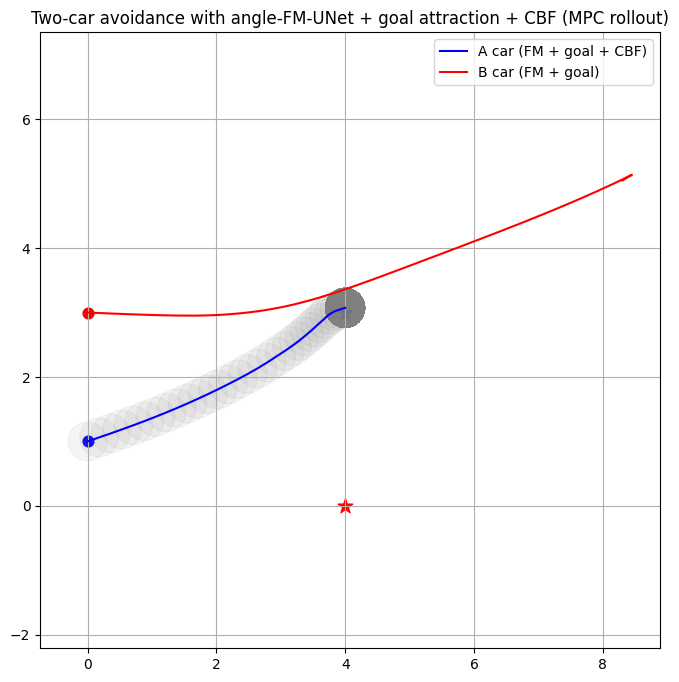

In [47]:
plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + goal + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM + goal)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o', s=60)
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*', s=120)

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o', s=60)
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*', s=120)

# A 车的安全圈（不画最后一个）
for i in range(len(xs_A) - 1):
    circle = plt.Circle(
        (xs_A[i, 0], xs_A[i, 1]),
        safe_radius,
        color='gray',
        alpha=0.08,
        edgecolor=None,
    )
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with angle-FM-UNet + goal attraction + CBF (MPC rollout)")
plt.show()


In [38]:
goal_stop_A  = 0.08
goal_stop_B  = 0.08
v_max        = 0.5   # 限速，防止一步走太多

def mpc_step_A_goal_cbf_angle(
    xA, xB, t_norm, model, goal_A, goal_B, ellipses=None
):
    # ---- B：简单 goal 控制 / FM 控制 都可以，在这里不细改 ----
    # 先假设你现在用 simple_goal_controller：
    dist_goal_B = np.linalg.norm(xB - goal_B)
    if dist_goal_B < goal_stop_B:
        vB = np.zeros(2, dtype=np.float32)
    else:
        vB = simple_goal_controller(xB, goal_B, v_max=0.4)

    # ---- A：如果已经很接近 goal_A，就停住 ----
    dist_goal_A = np.linalg.norm(xA - goal_A)
    if dist_goal_A < goal_stop_A:
        vA_safe = np.zeros(2, dtype=np.float32)
        xA_next = xA + vA_safe * dt
        xB_next = xB + vB      * dt
        return xA_next, xB_next, vA_safe, vB

    # ---- 正常：FM + goal 得到 vA_nom ----
    cond_vec_A = compute_theta_sincos_to_goal(xA, goal_A, device=device)
    xA_tensor  = torch.tensor(xA, dtype=torch.float32, device=device)

    vA_nom_tensor = make_goal_pulled_v_nom(
        xA_tensor=xA_tensor,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        cond_vec_A=cond_vec_A,
        kg=0.8,
        lam=0.3,
    )

    # ---- CBF 投影 ----
    xB_tensor_for_cbf = torch.tensor(xB, dtype=torch.float32, device=device)
    vA_safe_tensor = cbf_project_velocity_step(
        x_now_2=xA_tensor,
        v_nom_2=vA_nom_tensor,
        ellipses=ellipses,
        other_agent_pos_2=xB_tensor_for_cbf,
        agent_safe_radius=safe_radius,
        extra_margin=0.0,
        max_corr_norm=1.0,
        gamma_min=1.0,
        w_p=1.0,
        press_k=1.0,
        press_n=2.0,
    )
    vA_safe = vA_safe_tensor.detach().cpu().numpy()

    # ---- ⭐ 限速，防止速度太大 ----
    speed_A = np.linalg.norm(vA_safe)
    if speed_A > v_max:
        vA_safe = vA_safe / speed_A * v_max

    speed_B = np.linalg.norm(vB)
    if speed_B > v_max:
        vB = vB / speed_B * v_max

    # ---- 欧拉更新 ----
    xA_next = xA + vA_safe * dt
    xB_next = xB + vB      * dt

    return xA_next, xB_next, vA_safe, vB


In [39]:
goal_tol_A = 0.05
goal_tol_B = 0.05

xs_A = [xA.copy()]
xs_B = [xB.copy()]
vs_A = []
vs_B = []

for k in range(N_steps):
    t_norm = k / max(1, N_steps - 1)

    xA, xB, vA_safe, vB = mpc_step_A_goal_cbf_angle(
        xA=xA,
        xB=xB,
        t_norm=t_norm,
        model=model,
        goal_A=goal_A,
        goal_B=goal_B,
        ellipses=None,
    )

    xs_A.append(xA.copy())
    xs_B.append(xB.copy())
    vs_A.append(vA_safe.copy())
    vs_B.append(vB.copy())

    if (np.linalg.norm(xA - goal_A) < goal_tol_A and
        np.linalg.norm(xB - goal_B) < goal_tol_B):
        print(f"Both cars reached their goals at step {k}")
        break

xs_A = np.stack(xs_A, axis=0)
xs_B = np.stack(xs_B, axis=0)


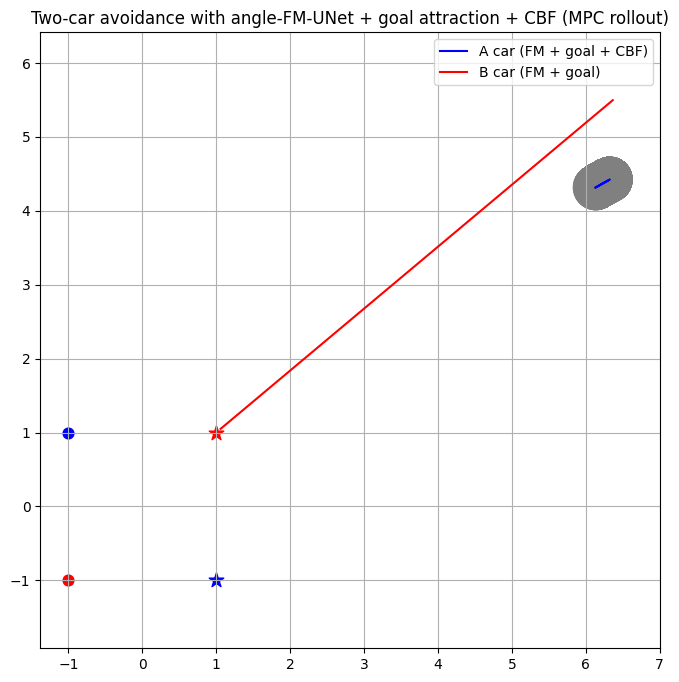

In [40]:
plt.figure(figsize=(8, 8))

plt.plot(xs_A[:, 0], xs_A[:, 1], 'b-', label='A car (FM + goal + CBF)')
plt.plot(xs_B[:, 0], xs_B[:, 1], 'r-', label='B car (FM + goal)')

plt.scatter(xA_0[0], xA_0[1], c='b', marker='o', s=60)
plt.scatter(goal_A[0], goal_A[1], c='b', marker='*', s=120)

plt.scatter(xB_0[0], xB_0[1], c='r', marker='o', s=60)
plt.scatter(goal_B[0], goal_B[1], c='r', marker='*', s=120)

# A 车的安全圈（不画最后一个）
for i in range(len(xs_A) - 1):
    circle = plt.Circle(
        (xs_A[i, 0], xs_A[i, 1]),
        safe_radius,
        color='gray',
        alpha=0.08,
        edgecolor=None,
    )
    plt.gca().add_patch(circle)

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Two-car avoidance with angle-FM-UNet + goal attraction + CBF (MPC rollout)")
plt.show()
